# **DINO V03**

In [ ]:
import os, time, random
import numpy as np
import pandas as pd
from dataclasses import dataclass
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import timm

# =========================
# CONFIGURATION
# =========================
# TRAIN_CSV = "/content/drive/MyDrive/FYP/foci_annotations/supervised_dataset/train_dataset.csv"
# VAL_CSV   = "/content/drive/MyDrive/FYP/foci_annotations/supervised_dataset/val_dataset.csv"
# TEST_CSV  = "/content/drive/MyDrive/FYP/foci_annotations/supervised_dataset/test_dataset.csv"


TRAIN_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_stratified/train_dataset.csv"
VAL_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_stratified/val_dataset.csv"
TEST_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_stratified/test_dataset.csv"


# TRAIN_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/cell_only/train_dataset.csv"
# VAL_CSV   = "/content/drive/MyDrive/FYP/natural foci ground truths/data/cell_only/val_dataset.csv"
# TEST_CSV  = "/content/drive/MyDrive/FYP/natural foci ground truths/data/cell_only/test_dataset.csv"


SSL_BACKBONE_SAVE_PATH = "/content/drive/MyDrive/FYP/natural foci ground truths/backbone models/CELL_ONLY_foci_dino_backbone_DINOv03_culture_stratified_v01.pth"

IMAGE_SIZE_GLOBAL = 384
IMAGE_SIZE_LOCAL  = 96
N_LOCAL_CROPS     = 4

LABEL_COL  = "label"
SPLIT_SEED = 42

BATCH_SSL  = 16
BATCH_EVAL = 16

NUM_EPOCHS          = 20
WARMUP_TEACHER_TEMP = 5      # epochs over which teacher temp ramps up
TEACHER_TEMP_START  = 0.04
TEACHER_TEMP_END    = 0.07
EVAL_EVERY          = 10
KNN_K               = 20

LR = 5e-4
WD = 1e-4

MOMENTUM_BASE  = 0.996
MOMENTUM_FINAL = 1.0

OUT_DIM        = 256
HIDDEN_DIM     = 2048
BOTTLENECK_DIM = 256


# cell + tissue
# NORM_MEAN = [0.1599, 0.1599, 0.1599]
# NORM_STD  = [0.1580, 0.1580, 0.1580]


# cell only
# TRAIN_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/train_dataset.csv"
# NORM_MEAN = [0.2251, 0.2251, 0.2251]
# NORM_STD  = [0.2375, 0.2375, 0.2375]


# cell only
# TRAIN_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/train_dataset.csv"
NORM_MEAN = [0.2267, 0.2267, 0.2267]
NORM_STD  = [0.2389, 0.2389, 0.2389]



# TRAIN_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/cell_only/train_dataset.csv"
# NORM_MEAN = [0.2856, 0.2856, 0.2856]
# NORM_STD  = [0.2241, 0.2241, 0.2241]


# TRAIN_CSV = "/content/drive/MyDrive/FYP/foci_annotations/supervised_dataset/train_dataset.csv"
# NORM_MEAN = [0.2269, 0.2269, 0.2269]
# NORM_STD  = [0.2390, 0.2390, 0.2390]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# =========================
# UTILS
# =========================
def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(SPLIT_SEED)

def exists_path(p):
    try: return os.path.exists(p)
    except: return False

def cosine_schedule(step, total_steps, base, final):
    """
    Works for both scalar step (momentum per batch)
    and numpy array step (pre-computing lr/wd schedules).
    """
    if total_steps <= 1: return final
    t = step / (total_steps - 1)
    return final - (final - base) * (0.5 * (1 + np.cos(np.pi * t)))

# =========================
# AUGMENTATIONS
# =========================
class AddMicroscopyNoise:
    def __init__(self, p=0.8, poisson_scale=(20, 80), gauss_sigma=(0.0, 0.03)):
        self.p = p; self.poisson_scale = poisson_scale; self.gauss_sigma = gauss_sigma
    def __call__(self, x):
        if torch.rand(1).item() > self.p: return x
        scale = torch.empty(1).uniform_(*self.poisson_scale).item()
        noisy = torch.poisson(x.clamp(0, 1) * scale) / scale
        sigma = torch.empty(1).uniform_(*self.gauss_sigma).item()
        if sigma > 0: noisy = noisy + sigma * torch.randn_like(noisy)
        return noisy.clamp(0, 1)

class RandomGamma:
    def __init__(self, p=0.4, gamma_range=(0.8, 1.25)):
        self.p = p; self.gamma_range = gamma_range
    def __call__(self, x):
        if torch.rand(1).item() > self.p: return x
        g = torch.empty(1).uniform_(*self.gamma_range).item()
        return x.clamp(0, 1).pow(g)

# Asymmetric global transforms — global_1 always blurred, global_2 rarely blurred
global_transform_1 = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE_GLOBAL, scale=(0.4, 1.0),
                        interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),   # always applied
    T.ToTensor(),
    AddMicroscopyNoise(p=0.85),
    RandomGamma(p=0.4),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

global_transform_2 = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE_GLOBAL, scale=(0.4, 1.0),
                        interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.1),  # rarely applied
    T.ToTensor(),
    AddMicroscopyNoise(p=0.85),
    RandomGamma(p=0.4),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

local_transform = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE_LOCAL, scale=(0.05, 0.4),
                        interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.5),
    T.ToTensor(),
    AddMicroscopyNoise(p=0.85),
    RandomGamma(p=0.4),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

eval_transform = T.Compose([
    T.Resize(int(IMAGE_SIZE_GLOBAL * 1.14), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMAGE_SIZE_GLOBAL),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

In [ ]:
# =========================
# DATASETS & LOADERS
# =========================
class DINOMultiCropDataset(Dataset):
    def __init__(self, df, global_tf1, global_tf2, local_tf,
                 n_local=4, max_retry=5, try_alt=6):
        self.paths      = df["image_path"].tolist()
        self.global_tf1 = global_tf1
        self.global_tf2 = global_tf2
        self.local_tf   = local_tf
        self.n_local    = n_local
        self.max_retry  = max_retry
        self.try_alt    = try_alt

    def __len__(self): return len(self.paths)

    def _open(self, path):
        for _ in range(self.max_retry):
            try:
                with Image.open(path) as im: return im.convert("RGB").copy()
            except (OSError, UnidentifiedImageError): time.sleep(0.05)
        raise RuntimeError(f"Cannot open {path}")

    def __getitem__(self, idx):
        for _ in range(self.try_alt):
            try:
                img = self._open(self.paths[idx])
                return (
                    [self.global_tf1(img), self.global_tf2(img)] +
                    [self.local_tf(img) for _ in range(self.n_local)]
                )
            except Exception:
                idx = random.randint(0, len(self.paths) - 1)
        return None

class LabeledDataset(Dataset):
    def __init__(self, df, transform, label_col="label", max_retry=5):
        self.paths     = df["image_path"].tolist()
        self.labels    = df[label_col].astype(int).tolist()
        self.transform = transform
        self.max_retry = max_retry

    def __len__(self): return len(self.paths)

    def _open(self, path):
        for _ in range(self.max_retry):
            try:
                with Image.open(path) as im: return im.convert("RGB").copy()
            except (OSError, UnidentifiedImageError): time.sleep(0.05)
        raise RuntimeError(f"Cannot open {path}")

    def __getitem__(self, idx):
        try:
            img = self._open(self.paths[idx])
            return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)
        except: return None

def dino_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    return [torch.stack([s[v] for s in batch]) for v in range(len(batch[0]))]

def sup_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    xs, ys = zip(*batch)
    return torch.stack(xs), torch.stack(ys)

print("Loading datasets...")
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)
df_test  = pd.read_csv(TEST_CSV)

df_train = df_train[df_train["image_path"].apply(exists_path)].reset_index(drop=True)
df_val   = df_val  [df_val  ["image_path"].apply(exists_path)].reset_index(drop=True)
df_test  = df_test [df_test ["image_path"].apply(exists_path)].reset_index(drop=True)
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

unlab_loader = DataLoader(
    DINOMultiCropDataset(df_train, global_transform_1, global_transform_2,
                         local_transform, N_LOCAL_CROPS),
    batch_size=BATCH_SSL, shuffle=True, num_workers=2,
    pin_memory=True, drop_last=True, collate_fn=dino_collate
)
train_eval_loader = DataLoader(
    LabeledDataset(df_train, eval_transform, LABEL_COL),
    batch_size=BATCH_EVAL, shuffle=False, num_workers=2, collate_fn=sup_collate
)
val_eval_loader = DataLoader(
    LabeledDataset(df_val, eval_transform, LABEL_COL),
    batch_size=BATCH_EVAL, shuffle=False, num_workers=2, collate_fn=sup_collate
)
test_eval_loader = DataLoader(
    LabeledDataset(df_test, eval_transform, LABEL_COL),
    batch_size=BATCH_EVAL, shuffle=False, num_workers=2, collate_fn=sup_collate
)

Loading datasets...
Train: 2088 | Val: 447 | Test: 448


In [ ]:
# =========================
# MODEL
# =========================
class ViTBackbone(nn.Module):
    def __init__(self, name="vit_tiny_patch16_384", pretrained=True):
        super().__init__()
        # dynamic_img_size=True: positional embeddings interpolated for 96x96 local crops
        self.vit = timm.create_model(
            name, pretrained=pretrained, num_classes=0,
            global_pool="", img_size=IMAGE_SIZE_GLOBAL, dynamic_img_size=True
        )

    def forward(self, x):
        feats = self.vit.forward_features(x)
        if isinstance(feats, dict): feats = feats.get("x", feats)
        if feats.dim() == 3: feats = feats[:, 0, :]   # CLS token only
        return feats

class DINOHead(nn.Module):
    """
      - 3-layer MLP: in_dim → hidden_dim → hidden_dim → bottleneck_dim
      - L2 normalisation before final projection (unit hypersphere)
      - Weight-normalised final layer with frozen scale (direction-only learning)
    """
    def __init__(self, in_dim, out_dim=256, hidden_dim=2048, bottleneck_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim,     hidden_dim),    nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),    nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.utils.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False)
        )
        self.last_layer.weight_g.data.fill_(1)
        self.last_layer.weight_g.requires_grad = False   # frozen scale

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)   # L2 normalisation
        x = self.last_layer(x)
        return x

class DINOStudentTeacher(nn.Module):
    def __init__(self, backbone_name="vit_tiny_patch16_384", pretrained=True):
        super().__init__()
        self.backbone = ViTBackbone(backbone_name, pretrained=pretrained)
        with torch.no_grad():
            in_dim = self.backbone(
                torch.zeros(1, 3, IMAGE_SIZE_GLOBAL, IMAGE_SIZE_GLOBAL)
            ).shape[-1]
        self.head = DINOHead(in_dim, OUT_DIM, HIDDEN_DIM, BOTTLENECK_DIM)

    def forward(self, x): return self.head(self.backbone(x))

In [ ]:
# =========================
# LOSS
# =========================
@dataclass
class DINOLossConfig:
    out_dim:         int   = OUT_DIM
    student_temp:    float = 0.1
    center_momentum: float = 0.9

class DINOLoss(nn.Module):
    def __init__(self, cfg: DINOLossConfig):
        super().__init__()
        self.cfg = cfg
        self.register_buffer("center", torch.zeros(1, cfg.out_dim))

    def forward(self, student_logits_list, teacher_logits_list, teacher_temp):
        st = self.cfg.student_temp
        tt = teacher_temp

        student_logp = [F.log_softmax(s / st, dim=-1) for s in student_logits_list]

        with torch.no_grad():
            teacher_probs = [
                F.softmax((t - self.center) / tt, dim=-1)
                for t in teacher_logits_list
            ]

        total_loss, n_terms = 0.0, 0
        for i, t_p in enumerate(teacher_probs):
            for j, s_lp in enumerate(student_logp):
                if j == i: continue   # skip same-view pairs
                total_loss += torch.sum(-t_p * s_lp, dim=-1).mean()
                n_terms    += 1

        with torch.no_grad():
            batch_center = torch.cat(teacher_logits_list, dim=0).mean(dim=0, keepdim=True)
            self.center  = (self.center * self.cfg.center_momentum
                            + batch_center * (1.0 - self.cfg.center_momentum))

        return total_loss / max(1, n_terms)

In [ ]:
# =========================
# OPTIMIZER & SCHEDULES
# =========================
def get_params_groups(model):
    """
    No weight decay on bias, norm, cls_token, pos_embed — matches original DINO.
    """
    params_wd, params_no_wd = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        if any(nd in name for nd in ["bias", "norm", "cls_token", "pos_embed"]):
            params_no_wd.append(param)
        else:
            params_wd.append(param)
    return [
        {"params": params_wd,    "weight_decay": WD},
        {"params": params_no_wd, "weight_decay": 0.0},
    ]

student = DINOStudentTeacher("vit_tiny_patch16_384", pretrained=True).to(device)
teacher = DINOStudentTeacher("vit_tiny_patch16_384", pretrained=True).to(device)

teacher.load_state_dict(student.state_dict())
for p in teacher.parameters(): p.requires_grad = False

dino_loss_fn = DINOLoss(DINOLossConfig()).to(device)
optimizer    = torch.optim.AdamW(get_params_groups(student), lr=LR)

# Pre-compute per-step schedules as arrays
total_steps  = NUM_EPOCHS * len(unlab_loader)
warmup_steps = 10 * len(unlab_loader)   # 10-epoch linear LR warmup

lr_schedule = np.concatenate([
    np.linspace(1e-6, LR, warmup_steps),
    cosine_schedule(
        np.arange(total_steps - warmup_steps),
        total_steps - warmup_steps,
        LR, 1e-6
    )
])

wd_schedule = cosine_schedule(
    np.arange(total_steps), total_steps, 0.04, 0.4
)

# Per-epoch teacher temperature schedule
teacher_temp_schedule = np.concatenate([
    np.linspace(TEACHER_TEMP_START, TEACHER_TEMP_END, WARMUP_TEACHER_TEMP),
    np.full(NUM_EPOCHS - WARMUP_TEACHER_TEMP, TEACHER_TEMP_END)
])

# =========================
# HELPERS
# =========================
@torch.no_grad()
def update_teacher(student, teacher, m):
    for ps, pt in zip(student.parameters(), teacher.parameters()):
        pt.data.mul_(m).add_(ps.data, alpha=1.0 - m)

@torch.no_grad()
def extract_features(backbone, loader):
    backbone.eval()
    feats_all, labels_all = [], []
    for batch in tqdm(loader, desc="Extracting", leave=False):
        if batch is None: continue
        x, y = batch; x = x.to(device, non_blocking=True)
        f = F.normalize(backbone(x), dim=-1)
        feats_all.append(f.cpu()); labels_all.append(y.cpu())
    if not feats_all: return None, None
    return torch.cat(feats_all), torch.cat(labels_all)

@torch.no_grad()
def knn_accuracy(tr_f, tr_y, va_f, va_y, k=20):
    sims        = va_f @ tr_f.T
    topk_labels = tr_y[sims.topk(k=k, dim=1).indices]
    num_classes = int(tr_y.max().item()) + 1
    preds       = [torch.bincount(row, minlength=num_classes).argmax().item()
                   for row in topk_labels]
    return (torch.tensor(preds) == va_y).float().mean().item()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/23.2M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [ ]:
# =========================
# TRAINING LOOP
# =========================
ssl_loss_history, knn_val_history = [], []
global_step = 0

os.makedirs(os.path.dirname(SSL_BACKBONE_SAVE_PATH), exist_ok=True)
print(f"\n[START] DINO training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):

    teacher_temp = teacher_temp_schedule[epoch]
    student.train(); teacher.eval()
    epoch_loss, n_batches = 0.0, 0

    for views in tqdm(unlab_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        if views is None: continue
        views = [v.to(device, non_blocking=True) for v in views]

        # Update LR & WD manually from pre-computed schedules
        # Clip step index to prevent off-by-one crash on final batch
        step_idx = min(global_step, total_steps - 1)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr_schedule[step_idx]
            if param_group["weight_decay"] > 0:
                param_group["weight_decay"] = wd_schedule[step_idx]

        # Forward pass
        # Split globals (384×384) and locals (96×96) before cat to avoid
        global_views = views[:2]
        local_views  = views[2:]

        s_globals = student(torch.cat(global_views, dim=0))   # (2B, out_dim)
        s_locals  = student(torch.cat(local_views,  dim=0))   # (4B, out_dim)

        student_outs = (
            list(s_globals.split(views[0].shape[0], dim=0)) +   # [s_g1, s_g2]
            list(s_locals.split(views[2].shape[0],  dim=0))     # [s_l1..s_l4]
        )

        with torch.no_grad():
            teacher_outs = [teacher(views[0]), teacher(views[1])]

        loss = dino_loss_fn(student_outs, teacher_outs, teacher_temp)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        # Freeze last layer for epoch 0
        # Prevents the randomly-initialised prototype vectors from being
        # updated before the rest of the head has stabilised
        if epoch == 0:
            for name, param in student.named_parameters():
                if "last_layer" in name and param.grad is not None:
                    param.grad = None

        # Gradient clipping (original DINO: max_norm=3.0)
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=3.0)

        optimizer.step()

        # EMA teacher update
        m = cosine_schedule(global_step, total_steps, MOMENTUM_BASE, MOMENTUM_FINAL)
        update_teacher(student, teacher, m)

        epoch_loss  += loss.item()
        n_batches   += 1
        global_step += 1

    avg_loss   = epoch_loss / max(1, n_batches)
    current_lr = optimizer.param_groups[0]["lr"]
    ssl_loss_history.append(avg_loss)

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | "
          f"LR: {current_lr:.2e} | Teacher Temp: {teacher_temp:.4f}")

    ckpt = SSL_BACKBONE_SAVE_PATH.replace(".pth", f"_epoch_{epoch+1}.pth")
    torch.save(teacher.backbone.state_dict(), ckpt)
    print(f"  Saved: {os.path.basename(ckpt)}")

    # kNN probe
    if (epoch + 1) % EVAL_EVERY == 0:
        print(f"\n[kNN probe] Epoch {epoch+1}...")
        tr_f, tr_y = extract_features(teacher.backbone, train_eval_loader)
        va_f, va_y = extract_features(teacher.backbone, val_eval_loader)
        if tr_f is not None and va_f is not None:
            acc = knn_accuracy(tr_f, tr_y, va_f, va_y, KNN_K)
            knn_val_history.append((epoch + 1, acc))
            print(f"  Val kNN Acc: {acc*100:.2f}%")
        student.train()   # restore train mode after eval


[START] DINO training for 20 epochs...


Epoch 1/20:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 01 | Loss: 5.5193 | LR: 5.06e-05 | Teacher Temp: 0.0400
  Saved: CELL_ONLY_foci_dino_backbone_DINOv03_culture_stratified_v01_epoch_1.pth


Epoch 2/20:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 02 | Loss: 5.4551 | LR: 1.00e-04 | Teacher Temp: 0.0475
  Saved: CELL_ONLY_foci_dino_backbone_DINOv03_culture_stratified_v01_epoch_2.pth


...

Epoch 20 | Loss: 4.6751 | LR: 1.00e-06 | Teacher Temp: 0.0700
  Saved: CELL_ONLY_foci_dino_backbone_DINOv03_culture_stratified_v01_epoch_20.pth

[kNN probe] Epoch 20...


Extracting:   0%|          | 0/131 [00:00<?, ?it/s]

Extracting:   0%|          | 0/28 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aa61c765da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7aa61c765da0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    ^if w.is_alive():^
^
    File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process' 
    ^ ^ ^^ ^  ^ ^ ^ ^ ^^^^^^
^  File "

  Val kNN Acc: 88.59%


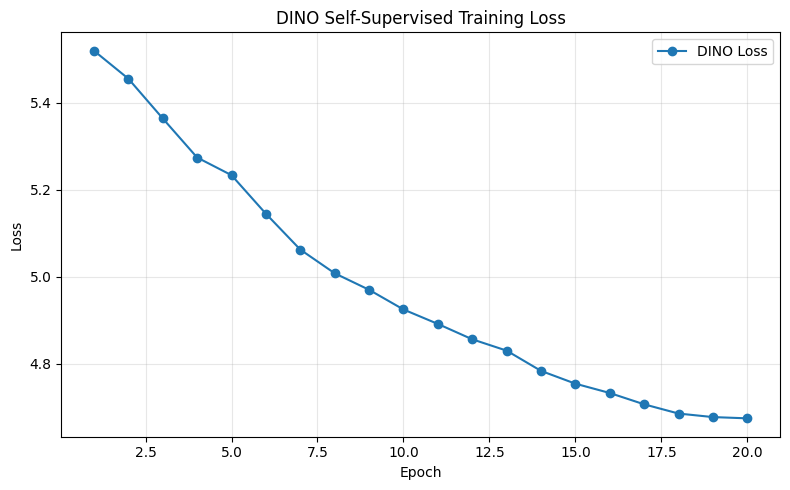


✅ Final backbone saved to: /content/drive/MyDrive/FYP/natural foci ground truths/backbone models/CELL_ONLY_foci_dino_backbone_DINOv03_culture_stratified_v01.pth

[Final Test kNN]


Extracting:   0%|          | 0/131 [00:00<?, ?it/s]

Extracting:   0%|          | 0/28 [00:00<?, ?it/s]

Test kNN Acc: 90.62%


In [ ]:
# =========================
# FINISH & SAVE
# =========================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ssl_loss_history) + 1), ssl_loss_history,
         marker="o", label="DINO Loss")
plt.title("DINO Self-Supervised Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

torch.save(teacher.backbone.state_dict(), SSL_BACKBONE_SAVE_PATH)
print(f"\nFinal backbone saved to: {SSL_BACKBONE_SAVE_PATH}")

print("\n[Final Test kNN]")
tr_f, tr_y = extract_features(teacher.backbone, train_eval_loader)
te_f, te_y = extract_features(teacher.backbone, test_eval_loader)
if tr_f is not None and te_f is not None:
    print(f"Test kNN Acc: {knn_accuracy(tr_f, tr_y, te_f, te_y, KNN_K)*100:.2f}%")

**Inspect**

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import timm
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.decomposition import PCA

# =========================
# 1. CONFIGURATION
# =========================
CSV_PATH      = "/content/drive/MyDrive/FYP/foci_annotations/supervised_dataset/test_dataset.csv"
# CSV_PATH  = "/content/drive/MyDrive/FYP/natural foci ground truths/data/cell_only/test_dataset.csv"
# CSV_PATH  = "/content/drive/MyDrive/FYP/foci_labels_v02.csv"
BACKBONE_CKPT = "/content/drive/MyDrive/FYP/natural foci ground truths/backbone models/CELL_ONLY_foci_dino_backbone_DINOv03_v03_epoch_15.pth"

NUM_IMAGES_TO_SHOW = 15
START_ROW          = 0

IMAGE_SIZE = 384
PATCH_SIZE = 16
GRID_SIZE  = IMAGE_SIZE // PATCH_SIZE   # 24x24 = 576 patches

# EXACT normalization from your V02 training script
NORM_MEAN = [0.2269, 0.2269, 0.2269]
NORM_STD  = [0.2390, 0.2390, 0.2390]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD BACKBONE
# =========================
backbone = timm.create_model(
    "vit_tiny_patch16_384",
    pretrained=False,
    num_classes=0,
    global_pool="",
    img_size=IMAGE_SIZE,
    dynamic_img_size=True
)

sd = torch.load(BACKBONE_CKPT, map_location="cpu")
sd = {k.replace("vit.", ""): v for k, v in sd.items() if k.startswith("vit.")}
backbone.load_state_dict(sd, strict=True)
backbone = backbone.to(DEVICE).eval()
print(f"Loaded DINO V02 Backbone ({len(sd)} keys)")

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

df = pd.read_csv(CSV_PATH)
selected_df = df.iloc[START_ROW : START_ROW + NUM_IMAGES_TO_SHOW].reset_index(drop=True)
print(f"Visualizing {len(selected_df)} images from test set\n")

# =========================
# EXTRACT RAW PATCH TOKENS
# =========================
@torch.no_grad()
def get_raw_patch_tokens(img_path):
    img = Image.open(img_path).convert("RGB")
    x   = eval_transform(img).unsqueeze(0).to(DEVICE)

    feats = backbone.forward_features(x)
    if isinstance(feats, dict):
        feats = feats.get("x", feats.get("pooled", feats))

    # feats shape: (1, 577, 192) -> We want [0, 1:, :] to skip the CLS token
    patch_tokens = feats[0, 1:, :]   # Shape: (576, 192)
    return patch_tokens.cpu(), img

# =========================
# VISUALIZE
# =========================
def norm_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

def visualize(patch_tokens, raw_img, label, img_name):
    tokens_np = patch_tokens.numpy()   # (576, 192)
    gt_label  = "Damaged" if label == 1 else "Healthy"

    # L2 Norm Map
    norms    = np.linalg.norm(tokens_np, axis=-1)
    norm_map = norm_01(norms.reshape(GRID_SIZE, GRID_SIZE))

    norm_overlay = Image.fromarray((norm_map * 255).astype(np.uint8)).resize(
        (IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR
    )

    # PCA RGB Map
    pca     = PCA(n_components=3)
    pca_out = pca.fit_transform(tokens_np)
    for c in range(3):
        pca_out[:, c] = norm_01(pca_out[:, c])
    rgb_map = pca_out.reshape(GRID_SIZE, GRID_SIZE, 3)

    # Plotting
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    axes[0].imshow(raw_img.resize((IMAGE_SIZE, IMAGE_SIZE)))
    axes[0].set_title(f"Original\nGT: {gt_label}", fontsize=10)
    axes[0].axis("off")

    im = axes[1].imshow(norm_map, cmap="magma")
    axes[1].set_title("Raw Patch Token Norms\n(High magnitude = important)", fontsize=10)
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(raw_img.resize((IMAGE_SIZE, IMAGE_SIZE)))
    axes[2].imshow(norm_overlay, cmap="magma", alpha=0.55)
    axes[2].set_title("Norm Overlay", fontsize=10)
    axes[2].axis("off")

    axes[3].imshow(rgb_map)
    axes[3].set_title("PCA Semantic Clustering\n(Similar features = similar colours)", fontsize=10)
    axes[3].axis("off")

    plt.suptitle(f"DINO V02 Patch Token Analysis  |  {img_name}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

for _, row in selected_df.iterrows():
    img_path = str(row["image_path"])
    label    = int(row.get("label", -1))
    img_name = os.path.basename(img_path)

    try:
        patch_tokens, raw_img = get_raw_patch_tokens(img_path)
        visualize(patch_tokens, raw_img, label, img_name)
    except Exception as e:
        print(f"Skipped {img_name}: {e}")